# Radical vs Populist: Transient Leadership in Opinion Dynamics

Extension of Albi, Calzola & Piu (2025) incorporating the **competing campaigning styles**
framework from Albi, Almi, Morandotti & Solombrino (2022, Section 5).

**Setup:** Two leader groups compete for influence over a mass population:
- **Radical** (Group R): Fixed target $\tilde{v}_R = 0.7$. Ideologically committed, never adapts.
- **Populist** (Group P): Moving target $\tilde{v}_P(t) = (1-w) \cdot m_v^{\mathrm{mass}}(t) + w \cdot 0.3$.
  Adapts message to current public opinion with a slight bias.

Both groups receive identical control resources ($\kappa^\star$ + $u^\star$, same $\gamma_v$).
Under **transient labels**, agents can join/leave groups based on contacts and
proximity to the group's *current* position — giving the populist a structural
advantage since its recruitment basin tracks the mass.


In [1]:
from __future__ import annotations
from dataclasses import dataclass, field, replace
from typing import Callable, Dict, List, Mapping, Optional, Sequence, Tuple
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from scipy.ndimage import gaussian_filter, gaussian_filter1d

try:
    from tqdm.auto import tqdm
except ImportError:
    def tqdm(it, **kw): return it

%matplotlib inline
plt.rcParams.update({"figure.dpi": 110, "figure.max_open_warning": 40})
print("Imports OK")

Imports OK


## Base Model (Albi et al. 2025, Table 1 + Algorithm 1)

In [2]:
MASS = 0
LEADER = 1
LEADER_A = 1
LEADER_B = 2

@dataclass
class BaseParams:
    beta: float = 1.0
    mu: float = 0.0
    c_bar: float = 200.0
    theta: float = 2.0
    delta_phi: float = 0.1
    nu: float = 0.1
    gamma_c: float = 1.0
    lam: float = 1.0
    alpha_R: float = 0.1
    alpha_H: float = 0.1
    r: float = 0.7
    rho_star: float = 0.5
    c_min: float = 100.0
    alpha: float = 1.0
    delta: float = 0.8
    p: float = 3.0
    v_tilde: float = 0.5
    sigma: float = 0.1
    gamma_v: float = 10.0

@dataclass
class RuntimeConfig:
    T: float
    dt: float
    Ns: int
    pair_fraction: float = 1.0
    v_bins: int = 220
    c_bins: int = 220
    c_max: float = 300.0
    c_clip_max: Optional[float] = None
    rho_bins: int = 320
    c_floor: float = 1e-8
    eta_dist: str = "uniform"
    pair_mode: str = "matching"
    influence_mode: str = "partner"
    joint_smooth_sigma: float = 1.1
    marginal_smooth_sigma: float = 1.0
    seed: int = 1234

@dataclass
class ScenarioControl:
    key: str
    title: str
    contact_groups: Tuple[int, ...] = ()
    opinion_groups: Tuple[int, ...] = ()
    gamma_v_by_group: Dict[int, float] = field(default_factory=dict)
    target_by_group: Dict[int, float] = field(default_factory=dict)

def table1_params():
    return BaseParams()

def make_runtime(test_id, mode="fast", seed=1234):
    T = {1: 50.0, 2: 50.0, 3: 150.0}[test_id]
    cfgs = {
        "fast":     {1: (1e-2, 12_000), 2: (1e-2, 16_000), 3: (1e-2, 18_000)},
        "balanced": {1: (1e-2, 24_000), 2: (1e-2, 30_000), 3: (1e-2, 60_000)},
        "paper":    {1: (1e-3, 1_000_000), 2: (1e-3, 1_000_000), 3: (1e-3, 1_000_000)},
    }
    dt, Ns = cfgs[mode][test_id]
    return RuntimeConfig(T=T, dt=dt, Ns=Ns, seed=seed)

def sigmoid(x):
    return 1.0 / (1.0 + np.exp(-np.clip(x, -60.0, 60.0)))

def psi_eps(s, beta, mu, eps):
    s = np.maximum(s, 1e-12)
    if abs(mu) < 1e-14:
        return np.zeros_like(s)
    s_eps = np.power(s, eps)
    return (1.0/(beta*eps)) * (mu/(1.0-mu)) * (s_eps-1.0) / (((1.0+mu)/(1.0-mu))*s_eps + 1.0)

def phi_v(v, m_v, theta, delta_phi):
    return theta * ((v - m_v)**2 - delta_phi**2)

def Rc(c, alpha_R, c_min):
    return sigmoid(alpha_R * (c_min - c))

def Hc_from_rho(rho, alpha_H, rho_star):
    return sigmoid(alpha_H * (rho - rho_star))

def D(v):
    return 1.0 - v**2

class LocalMassEstimator:
    def __init__(self, r, n_bins=320, v_min=-1.0, v_max=1.0):
        self.r, self.n_bins = float(r), int(n_bins)
        self.edges = np.linspace(v_min, v_max, n_bins + 1)
        self.dv = self.edges[1] - self.edges[0]
        self.window = max(0, int(np.ceil(self.r / self.dv)))
    def __call__(self, v):
        idx = np.clip(np.searchsorted(self.edges, v, side="right") - 1, 0, self.n_bins - 1)
        counts = np.bincount(idx, minlength=self.n_bins).astype(np.float64)
        csum = np.concatenate(([0.0], np.cumsum(counts)))
        bins = np.arange(self.n_bins)
        left = np.maximum(bins - self.window, 0)
        right = np.minimum(bins + self.window + 1, self.n_bins)
        rho_bins = (csum[right] - csum[left]) / max(float(v.size), 1.0)
        return rho_bins[idx]

def compromise_terms(vi, vj, ci, cj, delta, p, mode="partner"):
    close = (np.abs(vi - vj) < delta).astype(np.float64)
    ci_p = np.power(np.maximum(ci, 1e-12), p)
    cj_p = np.power(np.maximum(cj, 1e-12), p)
    den = ci_p + cj_p + 1e-14
    if mode == "partner":
        K_ij = cj_p / den
        K_ji = ci_p / den
    else:
        K_ij = ci_p / den
        K_ji = cj_p / den
    return close * K_ij, close * K_ji

def make_edges(cfg):
    v_e = np.linspace(-1.0, 1.0, cfg.v_bins + 1)
    c_e = np.linspace(0.0, cfg.c_max, cfg.c_bins + 1)
    return v_e, c_e, 0.5*(v_e[:-1]+v_e[1:]), 0.5*(c_e[:-1]+c_e[1:])

def joint_density(v, c, v_edges, c_edges, smooth_sigma=0.0):
    H, _, _ = np.histogram2d(v, c, bins=[v_edges, c_edges], density=False)
    if smooth_sigma > 0:
        H = gaussian_filter(H, sigma=smooth_sigma, mode="nearest")
    return H / (max(float(v.size), 1.0) * (v_edges[1]-v_edges[0]) * (c_edges[1]-c_edges[0]))

def marginal_density(x, edges, smooth_sigma=0.0):
    h, _ = np.histogram(x, bins=edges, density=False)
    if smooth_sigma > 0:
        h = gaussian_filter1d(h.astype(np.float64), sigma=smooth_sigma, mode="nearest")
    return h / (max(float(x.size), 1.0) * (edges[1]-edges[0]))

def _time_map(times, dt):
    return {int(round(float(t)/dt)): float(t) for t in times}

print("Base model defined")

Base model defined


## Radical vs Populist Simulation Engine

Key modifications to Algorithm 1:
1. **Step 0 — Label switching:** Before each step, agents can join/leave groups
   via a Markov process. Recruitment basin for the populist group *moves* with its target.
2. **Dynamic target:** Populist target $\tilde{v}_P(t)$ is recomputed each step
   from the current mass mean opinion. Radical target stays fixed.
3. **Control rebuild:** Control masks are rebuilt from current labels every step.


In [3]:
# ════════════════════════════════════════════════════════════════════════
#  RADICAL vs POPULIST: Simulation Engine
# ════════════════════════════════════════════════════════════════════════
#
#  Two campaigning styles (following Albi et al. 2022, Section 5):
#
#  RADICAL (Group A = LEADER_A):
#    Fixed target opinion v_R.  "True believer" who always pushes the
#    same message regardless of what the crowd thinks.
#    Opinion control: u* steers toward v_R = const.
#
#  POPULIST (Group B = LEADER_B):
#    Dynamic target v_P(t) that tracks the current mass opinion.
#    "Tells people what they want to hear" with a slight bias.
#    v_P(t) = (1-w) * m_v^mass(t)  +  w * v_pref
#    where m_v^mass = mean opinion of MASS agents,
#          v_pref  = populist's underlying preferred direction,
#          w       = conviction weight (0 = pure populist, 1 = radical).
#
#  Both groups receive contact control kappa* to maintain visibility.
#  Transient labels: agents switch groups based on contacts and
#  proximity to the group's CURRENT position (not initial position).
# ════════════════════════════════════════════════════════════════════════

MASS = 0
RADICAL = 1      # = LEADER_A
POPULIST = 2     # = LEADER_B

@dataclass
class RadPopConfig:
    """Parameters for the radical vs populist experiment."""
    # Radical group
    v_radical: float = 0.7          # fixed target opinion

    # Populist group
    v_pref_populist: float = 0.3    # underlying preference direction
    w_populist: float = 0.3         # conviction weight (0=pure populist, 1=radical)

    # Transient switching
    rate_promote: float = 0.3
    rate_demote: float = 0.3
    alpha_T: float = 0.05
    c_threshold: float = 70.0       # contacts needed to join a group
    opinion_width: float = 0.4      # half-width of recruitment basin
    rho_threshold: float = 0.15     # local density needed
    max_leader_frac: float = 0.45   # carrying capacity


def init_radical_populist(Ns, seed=1234):
    """Initial condition for radical vs populist experiment.

    15% Radical:  c ~ U[180,220], v ~ U[0.6, 0.8]  (extreme, well-connected)
    15% Populist: c ~ U[180,220], v ~ U[0.1, 0.4]  (moderate, well-connected)
    70% Mass:     c ~ U[30, 80],  v ~ U[-0.6, 0.2]  (low contacts, leaning negative)
    """
    rng = np.random.default_rng(seed)
    nr = int(round(0.15 * Ns))
    np_ = int(round(0.15 * Ns))
    nm = Ns - nr - np_

    v = np.empty(Ns, dtype=np.float64)
    c = np.empty(Ns, dtype=np.float64)
    g = np.empty(Ns, dtype=np.int32)

    # Radical group
    c[:nr] = rng.uniform(180, 220, nr)
    v[:nr] = rng.uniform(0.6, 0.8, nr)
    g[:nr] = RADICAL

    # Populist group
    s, e = nr, nr + np_
    c[s:e] = rng.uniform(180, 220, np_)
    v[s:e] = rng.uniform(0.1, 0.4, np_)
    g[s:e] = POPULIST

    # Mass
    c[e:] = rng.uniform(30, 80, nm)
    v[e:] = rng.uniform(-0.6, 0.2, nm)
    g[e:] = MASS

    perm = rng.permutation(Ns)
    return v[perm], c[perm], g[perm]


def run_radical_populist_sim(
    v0, c0, groups0, params, cfg, rpc,
    snapshot_times, marginal_times,
    transient=True, progress=True,
):
    """Simulation with radical vs populist dynamics.

    The key difference from the standard simulation: the populist group's
    target opinion is recomputed each step as a blend of the current mass
    mean and the populist's underlying preference.
    """
    rng = np.random.default_rng(cfg.seed)
    v = v0.copy().astype(np.float64)
    c = c0.copy().astype(np.float64)
    g = groups0.copy().astype(np.int32)
    N = v.size
    Nt = int(round(cfg.T / cfg.dt))
    eps = cfg.dt
    n_pairs = max(1, min(int(round(0.5 * cfg.pair_fraction * N)), N // 2))
    v_edges, c_edges, v_centers, c_centers = make_edges(cfg)
    snap_s = _time_map(snapshot_times, cfg.dt)
    marg_s = _time_map(marginal_times, cfg.dt)
    joint_snap, c_snap, v_snap = {}, {}, {}

    if 0 in snap_s:
        joint_snap[snap_s[0]] = joint_density(v, c, v_edges, c_edges, cfg.joint_smooth_sigma)
    if 0 in marg_s:
        c_snap[marg_s[0]] = marginal_density(c, c_edges, cfg.marginal_smooth_sigma)
        v_snap[marg_s[0]] = marginal_density(v, v_edges, cfg.marginal_smooth_sigma)

    mc = np.empty(Nt + 1)
    mv = np.empty(Nt + 1)
    frac_R = np.empty(Nt + 1)
    frac_P = np.empty(Nt + 1)
    target_P_history = np.empty(Nt + 1)  # track populist's moving target
    mc[0], mv[0] = np.mean(c), np.mean(v)
    frac_R[0] = np.mean(g == RADICAL)
    frac_P[0] = np.mean(g == POPULIST)

    # Initial populist target
    mass_mask = (g == MASS)
    if np.any(mass_mask):
        m_v_mass = float(np.mean(v[mass_mask]))
    else:
        m_v_mass = 0.0
    target_P_history[0] = (1 - rpc.w_populist) * m_v_mass + rpc.w_populist * rpc.v_pref_populist

    rho_est = LocalMassEstimator(r=params.r, n_bins=cfg.rho_bins)
    sqrt_eps = np.sqrt(eps)
    it = tqdm(range(Nt), desc="Rad vs Pop", leave=False) if progress else range(Nt)

    for n in it:
        # ═══ Compute current populist target ═══
        mass_mask = (g == MASS)
        if np.any(mass_mask):
            m_v_mass = float(np.mean(v[mass_mask]))
        else:
            m_v_mass = float(np.mean(v))

        v_target_P = (1 - rpc.w_populist) * m_v_mass + rpc.w_populist * rpc.v_pref_populist
        v_target_R = rpc.v_radical  # always fixed

        m_v = float(np.mean(v))

        # ═══ STEP 0: TRANSIENT LABEL SWITCHING ═══
        if transient:
            rho_all = rho_est(v)
            high_c = c > rpc.c_threshold
            high_rho = rho_all > rpc.rho_threshold

            # Recruitment basins — populist basin MOVES with its target!
            near_R = np.abs(v - v_target_R) < rpc.opinion_width
            near_P = np.abs(v - v_target_P) < rpc.opinion_width

            cur_frac = np.mean(g != MASS)
            p_join = rpc.rate_promote * eps
            p_lose = rpc.rate_demote * eps

            if cur_frac < rpc.max_leader_frac:
                coins = rng.uniform(size=N)
                g[(g == MASS) & near_R & high_c & high_rho & (coins < p_join)] = RADICAL
                coins = rng.uniform(size=N)
                g[(g == MASS) & near_P & high_c & high_rho & (coins < p_join)] = POPULIST

            # Demotion: opinion drifted away from group position OR contacts dropped
            coins = rng.uniform(size=N)
            g[(g == RADICAL) & (~near_R | ~high_c) & (coins < p_lose)] = MASS
            coins = rng.uniform(size=N)
            g[(g == POPULIST) & (~near_P | ~high_c) & (coins < p_lose)] = MASS

        # ═══ STEP 1: BUILD CONTROL MASKS FROM CURRENT LABELS ═══
        is_R = (g == RADICAL)
        is_P = (g == POPULIST)
        ce = is_R | is_P            # contact control on both groups
        oe = is_R | is_P            # opinion control on both groups

        # Build target array: radical=fixed, populist=dynamic
        tgt_arr = np.full(N, params.v_tilde)
        tgt_arr[is_R] = v_target_R
        tgt_arr[is_P] = v_target_P  # <-- the key: this changes every step

        gv_arr = np.full(N, params.gamma_v)
        gv_arr[is_R] = 1.0    # both groups have same control penalization
        gv_arr[is_P] = 1.0

        # ═══ STEP 2: STANDARD ALGORITHM 1 ═══
        perm = rng.permutation(N)
        paired = perm[:2 * n_pairs].reshape(n_pairs, 2)
        i, j = paired[:, 0], paired[:, 1]
        vi, vj, ci, cj = v[i], v[j], c[i], c[j]

        phi_i = phi_v(vi, m_v, params.theta, params.delta_phi)
        phi_j = phi_v(vj, m_v, params.theta, params.delta_phi)

        # Contact control kappa*
        kappa_i, kappa_j = np.zeros(n_pairs), np.zeros(n_pairs)
        if np.any(ce):
            rho2 = rho_est(v)
            hc = Hc_from_rho(rho2, params.alpha_H, params.rho_star)
            kp = params.lam * params.beta / params.gamma_c
            kappa_i = kp * Rc(ci, params.alpha_R, params.c_min) * hc[i] * ce[i]
            kappa_j = kp * Rc(cj, params.alpha_R, params.c_min) * hc[j] * ce[j]

        Pij, Pji = compromise_terms(vi, vj, ci, cj, params.delta, params.p,
                                    mode=cfg.influence_mode)

        # Opinion control u*
        u_i, u_j = np.zeros(n_pairs), np.zeros(n_pairs)
        if np.any(oe):
            ti = vi + eps * params.alpha * Pij * (vj - vi) - tgt_arr[i]
            tj = vj + eps * params.alpha * Pji * (vi - vj) - tgt_arr[j]
            u_i = -ti / (gv_arr[i] + eps * params.alpha) * oe[i]
            u_j = -tj / (gv_arr[j] + eps * params.alpha) * oe[j]

        # Noise
        amp = np.sqrt(3.0) * sqrt_eps * params.nu
        eta_i = amp * rng.uniform(-1, 1, n_pairs)
        eta_j = amp * rng.uniform(-1, 1, n_pairs)
        xi_i, xi_j = rng.normal(size=n_pairs), rng.normal(size=n_pairs)

        # Update contacts
        psi_i = psi_eps(ci / params.c_bar, params.beta, params.mu, eps)
        psi_j = psi_eps(cj / params.c_bar, params.beta, params.mu, eps)
        ci_new = ci - eps * params.beta * (psi_i + phi_i - kappa_i) * ci + eta_i * ci
        cj_new = cj - eps * params.beta * (psi_j + phi_j - kappa_j) * cj + eta_j * cj
        c[i] = np.maximum(ci_new, cfg.c_floor)
        c[j] = np.maximum(cj_new, cfg.c_floor)

        # Update opinions
        v[i] = np.clip(vi + eps*params.alpha*(Pij*(vj-vi)+u_i) + sqrt_eps*params.sigma*D(vi)*xi_i, -1, 1)
        v[j] = np.clip(vj + eps*params.alpha*(Pji*(vi-vj)+u_j) + sqrt_eps*params.sigma*D(vj)*xi_j, -1, 1)

        mc[n+1], mv[n+1] = np.mean(c), np.mean(v)
        frac_R[n+1] = np.mean(g == RADICAL)
        frac_P[n+1] = np.mean(g == POPULIST)
        target_P_history[n+1] = v_target_P

        step = n + 1
        if step in snap_s:
            joint_snap[snap_s[step]] = joint_density(v, c, v_edges, c_edges, cfg.joint_smooth_sigma)
        if step in marg_s:
            c_snap[marg_s[step]] = marginal_density(c, c_edges, cfg.marginal_smooth_sigma)
            v_snap[marg_s[step]] = marginal_density(v, v_edges, cfg.marginal_smooth_sigma)

    return {"times": np.arange(Nt+1)*cfg.dt, "mc": mc, "mv": mv,
            "frac_R": frac_R, "frac_P": frac_P, "target_P": target_P_history,
            "joint": joint_snap, "contact_marginals": c_snap, "opinion_marginals": v_snap,
            "v_edges": v_edges, "c_edges": c_edges,
            "v_centers": v_centers, "c_centers": c_centers,
            "final_v": v, "final_c": c, "groups": g}

print("Radical vs Populist engine defined")

Radical vs Populist engine defined


## Experiment Functions

In [4]:
# ════════════════════════════════════════════════════════════════════════
#  EXPERIMENT: Radical vs Populist Competition
# ════════════════════════════════════════════════════════════════════════
#
#  Inspired by Albi et al. (2022) Section 5: two competing leader groups
#  with different "campaigning styles."
#
#  RADICAL:  Fixed target v_R = 0.7.  Like a political party with a firm
#    ideological commitment that never wavers.
#    Advantage:  consistent message, attracts true believers.
#    Disadvantage: target far from mass opinion → hard to recruit.
#
#  POPULIST: Moving target v_P(t) = (1-w)*m_v^mass(t) + w*0.3.
#    Like a politician who adjusts their message to match public sentiment
#    but with a slight positive bias.
#    Advantage:  target always near the mass → easy to recruit.
#    Disadvantage: no fixed anchor, message changes constantly.
#
#  Both groups get identical control resources (same gamma_v, same kappa*).
#  Under TRANSIENT labels, agents join whichever group's current position
#  is close to their opinion — so the populist's moving recruitment basin
#  is a structural advantage.
#
#  Scenarios:
#    (a) Fixed labels — groups are permanent, like party registration
#    (b) Transient labels — fluid membership, like social media followership
# ════════════════════════════════════════════════════════════════════════

def run_radpop_experiment(mode="fast", seed=5555, progress=True):
    params = table1_params()
    params.gamma_v = 1.0   # moderate control penalization
    cfg = make_runtime(1, mode=mode, seed=seed)
    cfg = replace(cfg, T=60.0)  # run a bit longer to see competition play out
    v0, c0, g0 = init_radical_populist(cfg.Ns, cfg.seed)
    v_edges, c_edges, v_centers, c_centers = make_edges(cfg)
    ij = joint_density(v0, c0, v_edges, c_edges, cfg.joint_smooth_sigma)

    rpc = RadPopConfig(
        v_radical=0.7,
        v_pref_populist=0.3,
        w_populist=0.3,           # 70% mass-tracking + 30% own preference
        rate_promote=0.3,
        rate_demote=0.3,
        c_threshold=70.0,
        opinion_width=0.4,
        rho_threshold=0.15,
        max_leader_frac=0.45,
    )

    snap_t = [1.0, 5.0, 15.0, 30.0, 60.0]
    marg_t = [0.0, 1.0, 5.0, 15.0, 30.0, 60.0]

    # (a) Fixed labels
    cfg_a = replace(cfg, seed=cfg.seed + 100)
    res_fixed = run_radical_populist_sim(
        v0, c0, g0, params, cfg_a, rpc, snap_t, marg_t,
        transient=False, progress=progress)

    # (b) Transient labels
    cfg_b = replace(cfg, seed=cfg.seed + 200)
    res_trans = run_radical_populist_sim(
        v0, c0, g0, params, cfg_b, rpc, snap_t, marg_t,
        transient=True, progress=progress)

    return {"config": cfg, "params": params, "rpc": rpc,
            "v0": v0, "c0": c0, "groups0": g0, "initial_joint": ij,
            "v_edges": v_edges, "c_edges": c_edges,
            "v_centers": v_centers, "c_centers": c_centers,
            "fixed": res_fixed, "transient": res_trans}


def plot_radpop(exp):
    rf, rt = exp["fixed"], exp["transient"]
    rpc = exp["rpc"]

    fig, axes = plt.subplots(3, 3, figsize=(16, 13))

    # ── Row 0: Mean contacts, Mean opinion, Group fractions ──
    for label, res, st in [("Fixed", rf, "b-"), ("Transient", rt, "r--")]:
        t = res["times"]
        axes[0,0].plot(t, res["mc"], st, lw=2, label=label)
        axes[0,1].plot(t, res["mv"], st, lw=2, label=label)
        axes[0,2].plot(t, res["frac_R"], st, lw=2, label=f"{label}: Radical")
        axes[0,2].plot(t, res["frac_P"], st[0]+":", lw=2, label=f"{label}: Populist", alpha=0.7)

    axes[0,0].set_xlabel("$t$"); axes[0,0].set_ylabel("$m_c(t)$")
    axes[0,0].set_title("Mean contacts"); axes[0,0].legend(); axes[0,0].grid(alpha=0.25)
    axes[0,1].set_xlabel("$t$"); axes[0,1].set_ylabel("$m_v(t)$")
    axes[0,1].set_title("Mean opinion")
    axes[0,1].axhline(rpc.v_radical, color="tab:blue", ls=":", lw=1, alpha=0.5, label=f"Radical target={rpc.v_radical}")
    axes[0,1].legend(fontsize=8); axes[0,1].grid(alpha=0.25)
    axes[0,2].set_xlabel("$t$"); axes[0,2].set_ylabel("Fraction")
    axes[0,2].set_title("Group fractions")
    axes[0,2].legend(fontsize=7); axes[0,2].grid(alpha=0.25)

    # ── Row 1: Populist target evolution, joint densities ──
    # Populist moving target
    axes[1,0].plot(rf["times"], rf["target_P"], "b-", lw=2, label="Fixed")
    axes[1,0].plot(rt["times"], rt["target_P"], "r--", lw=2, label="Transient")
    axes[1,0].axhline(rpc.v_radical, color="tab:blue", ls=":", lw=1, alpha=0.5)
    axes[1,0].set_xlabel("$t$"); axes[1,0].set_ylabel("$\\tilde{v}_P(t)$")
    axes[1,0].set_title("Populist target (moving)")
    axes[1,0].legend(); axes[1,0].grid(alpha=0.25)

    # Joint densities at final time
    v_e, c_e = exp["v_edges"], exp["c_edges"]
    last_t = max(rf["joint"].keys())
    axes[1,1].pcolormesh(v_e, c_e, rf["joint"][last_t].T, cmap="turbo", shading="auto")
    axes[1,1].set_xlabel("$v$"); axes[1,1].set_ylabel("$c$")
    axes[1,1].set_title(f"Fixed | t={last_t:g}")
    axes[1,2].pcolormesh(v_e, c_e, rt["joint"][last_t].T, cmap="turbo", shading="auto")
    axes[1,2].set_xlabel("$v$"); axes[1,2].set_ylabel("$c$")
    axes[1,2].set_title(f"Transient | t={last_t:g}")

    # ── Row 2: Opinion marginals at multiple times ──
    vc = exp["v_centers"]
    plot_ts = sorted(rf["opinion_marginals"].keys())
    sel_ts = [plot_ts[0], plot_ts[len(plot_ts)//2], plot_ts[-1]]
    cmap_f = plt.cm.Blues
    cmap_t = plt.cm.Reds

    for idx, st in enumerate(sel_ts):
        ax = axes[2, idx]
        if st in rf["opinion_marginals"]:
            ax.plot(vc, rf["opinion_marginals"][st], "b-", lw=2, label="Fixed")
        if st in rt["opinion_marginals"]:
            ax.plot(vc, rt["opinion_marginals"][st], "r--", lw=2, label="Transient")
        ax.axvline(rpc.v_radical, color="tab:blue", ls=":", lw=1, alpha=0.5)
        # Show populist target at this time
        step_idx = int(round(st / exp["config"].dt))
        step_idx = min(step_idx, len(rt["target_P"]) - 1)
        ax.axvline(rt["target_P"][step_idx], color="tab:red", ls=":", lw=1, alpha=0.5)
        ax.set_xlabel("$v$"); ax.set_ylabel("$g(v)$")
        ax.set_title(f"Opinion distribution | t={st:g}")
        ax.legend(fontsize=8)

    fig.suptitle("Radical vs Populist: Fixed labels vs Transient membership",
                 fontsize=14, y=1.01)
    fig.tight_layout()
    return fig


def run_conviction_scan(mode="fast", seed=6666, progress=True):
    """Scan the populist conviction weight w from 0 (pure populist) to 0.8 (quasi-radical)."""
    params = table1_params()
    params.gamma_v = 1.0
    cfg = make_runtime(1, mode=mode, seed=seed)
    cfg = replace(cfg, T=60.0)

    snap_t = [60.0]
    marg_t = [0.0, 60.0]
    ws = [0.0, 0.15, 0.3, 0.5, 0.7]

    results = {}
    for w in ws:
        v0, c0, g0 = init_radical_populist(cfg.Ns, cfg.seed)
        rpc = RadPopConfig(
            v_radical=0.7, v_pref_populist=0.3, w_populist=w,
            rate_promote=0.3, rate_demote=0.3,
            c_threshold=70.0, opinion_width=0.4,
            rho_threshold=0.15, max_leader_frac=0.45)
        cfg_k = replace(cfg, seed=cfg.seed + int(w * 1000))
        res = run_radical_populist_sim(
            v0, c0, g0, params, cfg_k, rpc, snap_t, marg_t,
            transient=True, progress=progress)
        results[w] = res

    return results


def plot_conviction_scan(scan_results):
    ws = sorted(scan_results.keys())
    fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))

    frac_R_final = [scan_results[w]["frac_R"][-1] for w in ws]
    frac_P_final = [scan_results[w]["frac_P"][-1] for w in ws]
    mv_final = [scan_results[w]["mv"][-1] for w in ws]
    mc_final = [scan_results[w]["mc"][-1] for w in ws]

    axes[0].plot(ws, frac_R_final, "s-", color="tab:blue", lw=2, ms=8, label="Radical")
    axes[0].plot(ws, frac_P_final, "o--", color="tab:red", lw=2, ms=8, label="Populist")
    axes[0].set_xlabel("Populist conviction $w$"); axes[0].set_ylabel("Final fraction")
    axes[0].set_title("Group size vs conviction")
    axes[0].legend(); axes[0].grid(alpha=0.25)

    axes[1].plot(ws, mv_final, "k^-", lw=2, ms=8)
    axes[1].axhline(0.7, color="tab:blue", ls=":", alpha=0.5, label="Radical target")
    axes[1].axhline(0.3, color="tab:red", ls=":", alpha=0.5, label="Populist pref")
    axes[1].set_xlabel("Populist conviction $w$"); axes[1].set_ylabel("$m_v(T)$")
    axes[1].set_title("Final mean opinion")
    axes[1].legend(); axes[1].grid(alpha=0.25)

    axes[2].plot(ws, mc_final, "kD-", lw=2, ms=8)
    axes[2].set_xlabel("Populist conviction $w$"); axes[2].set_ylabel("$m_c(T)$")
    axes[2].set_title("Final mean contacts")
    axes[2].grid(alpha=0.25)

    fig.suptitle("Effect of populist conviction weight $w$ (transient labels)",
                 fontsize=13, y=1.02)
    fig.tight_layout()
    return fig

print("Experiment functions defined")

Experiment functions defined


---
## Main Experiment: Fixed vs Transient Labels

Initial condition: 15% Radical ($v \sim [0.6,0.8]$, $c \sim [180,220]$),
15% Populist ($v \sim [0.1,0.4]$, $c \sim [180,220]$),
70% Mass ($v \sim [-0.6,0.2]$, $c \sim [30,80]$).

The mass leans slightly negative — far from the radical's target (0.7)
but close to the populist's moving target.


Rad vs Pop:   0%|          | 0/6000 [00:00<?, ?it/s]

Rad vs Pop:   0%|          | 0/6000 [00:00<?, ?it/s]

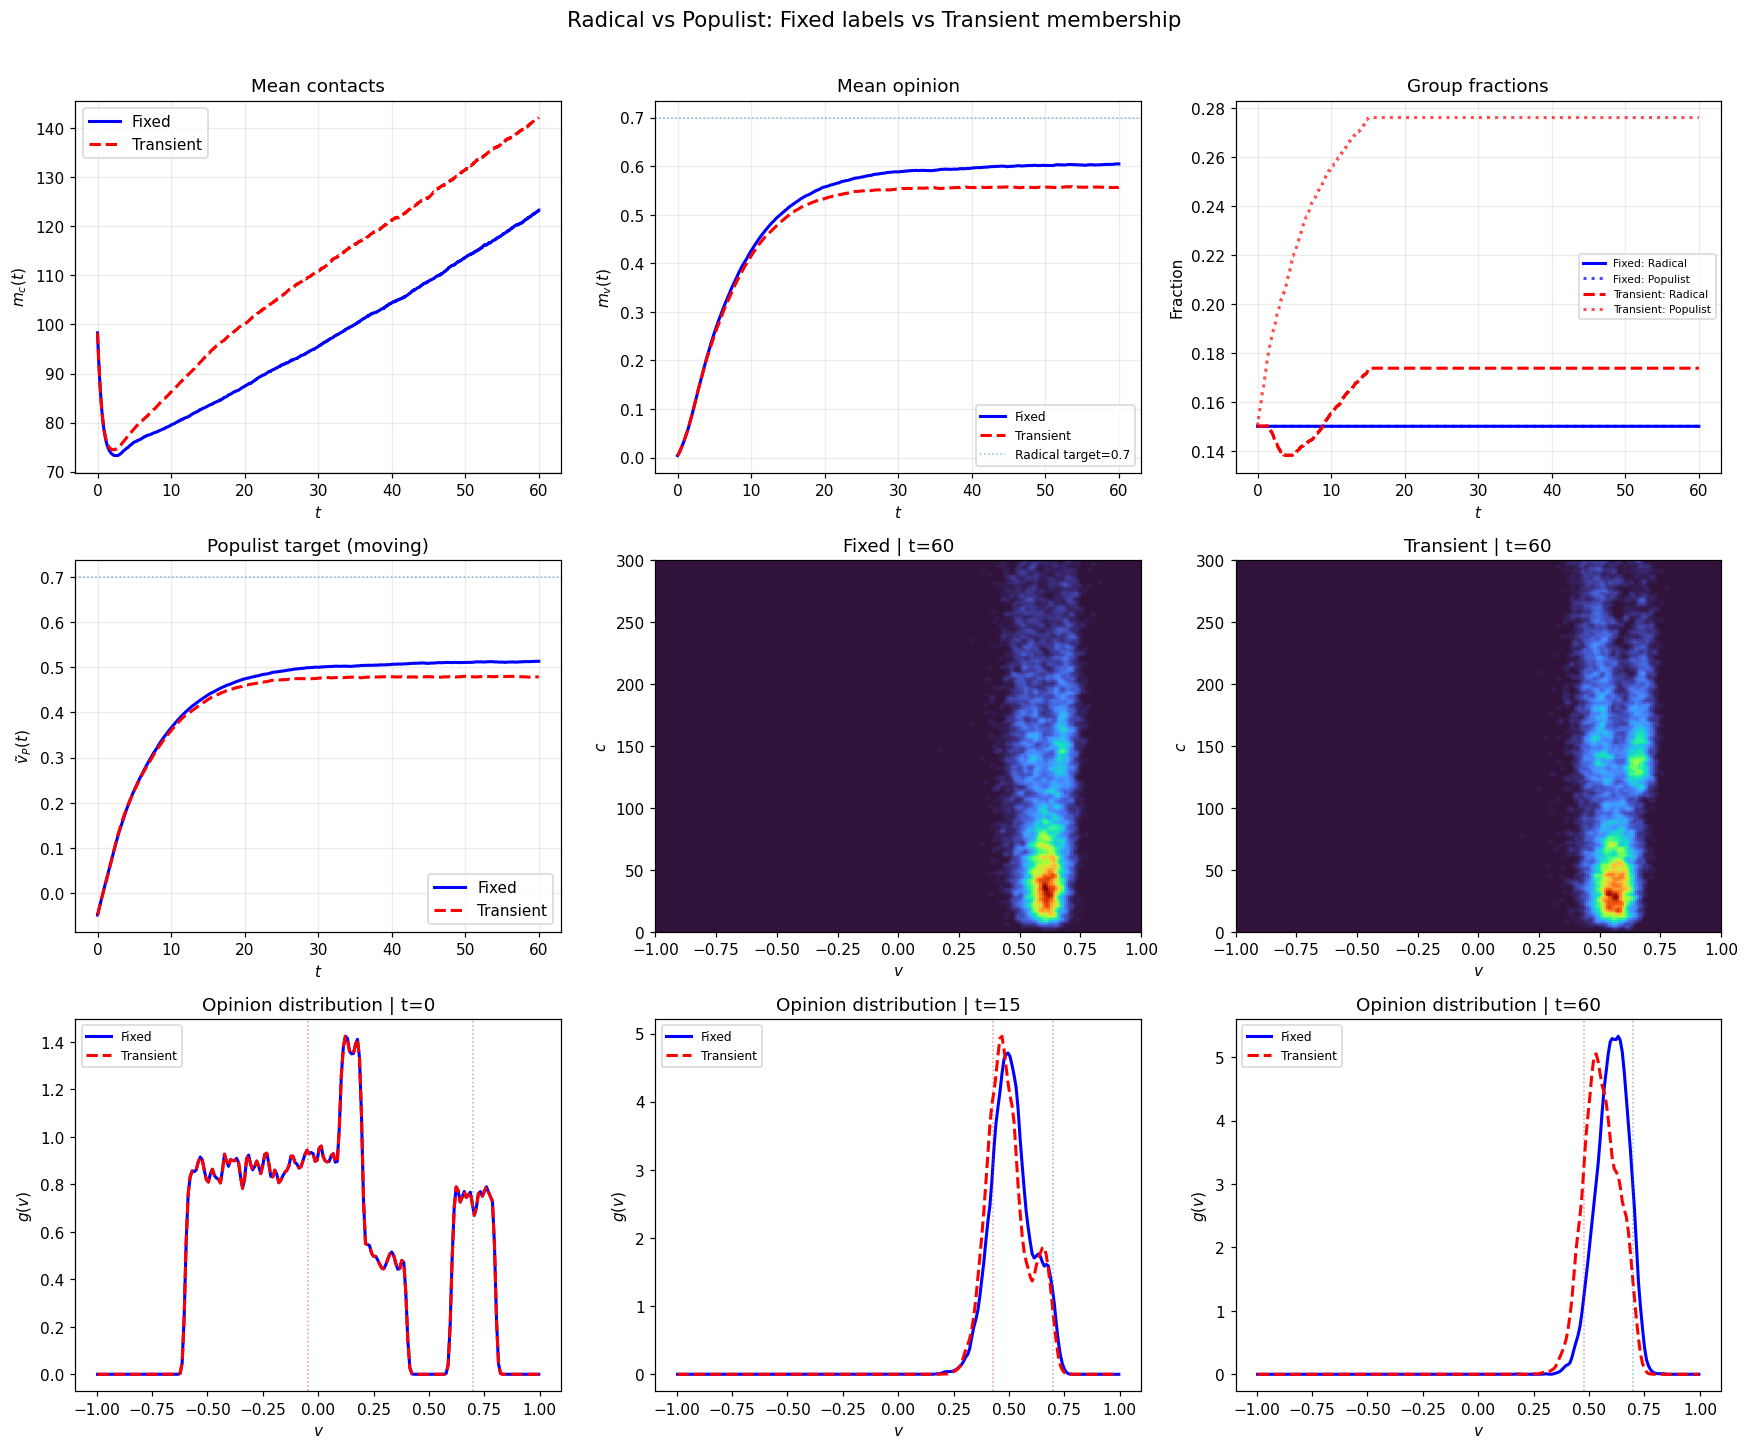

In [5]:
exp = run_radpop_experiment(mode="fast")
plot_radpop(exp)
plt.show()

---
## Conviction Scan: What happens as the populist becomes more ideological?

$w = 0$: pure populist (just echoes the mass).  
$w = 0.7$: quasi-radical (mostly pushes own agenda).  

Scan $w \in \{0, 0.15, 0.3, 0.5, 0.7\}$ under transient labels.


Rad vs Pop:   0%|          | 0/6000 [00:00<?, ?it/s]

Rad vs Pop:   0%|          | 0/6000 [00:00<?, ?it/s]

Rad vs Pop:   0%|          | 0/6000 [00:00<?, ?it/s]

Rad vs Pop:   0%|          | 0/6000 [00:00<?, ?it/s]

Rad vs Pop:   0%|          | 0/6000 [00:00<?, ?it/s]

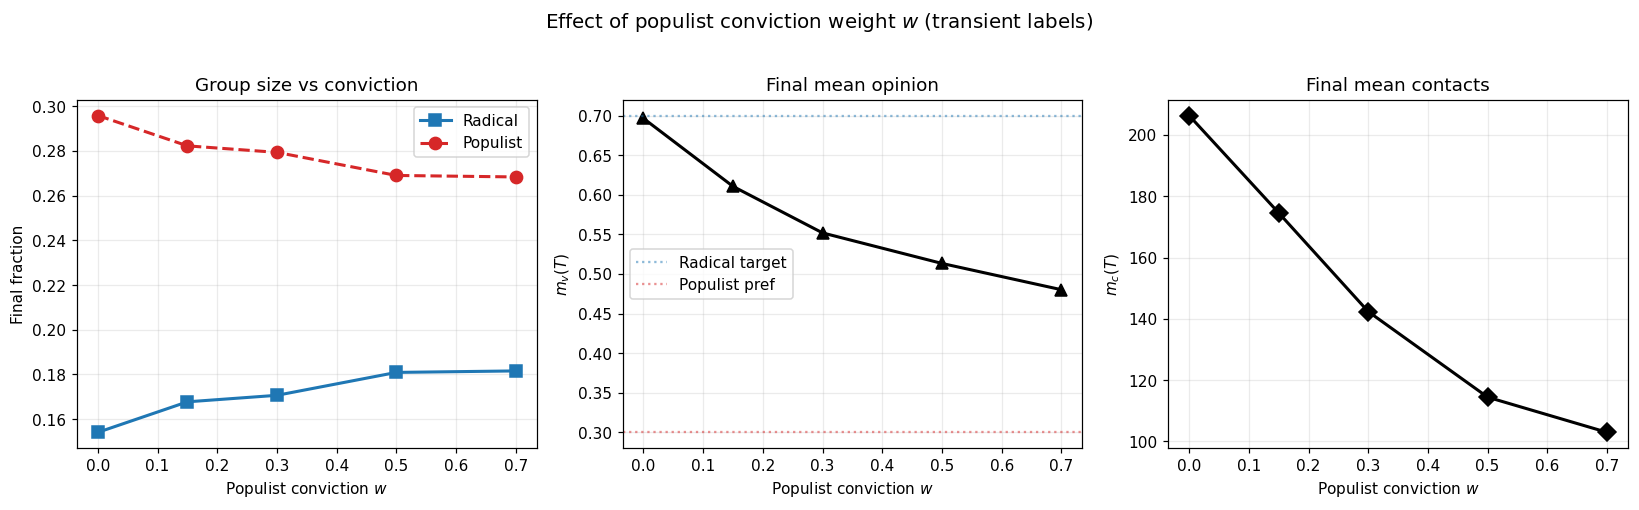

In [6]:
scan = run_conviction_scan(mode="fast")
plot_conviction_scan(scan)
plt.show()

---
## Summary

In [7]:
print("=" * 70)
print("  RADICAL vs POPULIST: Main Experiment")
print("=" * 70)
rpc = exp["rpc"]
print(f"  Radical target:  {rpc.v_radical} (fixed)")
print(f"  Populist pref:   {rpc.v_pref_populist}, w={rpc.w_populist}")
print()
for label, res in [("Fixed", exp["fixed"]), ("Transient", exp["transient"])]:
    print(f"  {label:12s}:  mc={res['mc'][-1]:6.1f}  mv={res['mv'][-1]:+.4f}  "
          f"R={res['frac_R'][-1]:.3f}  P={res['frac_P'][-1]:.3f}  "
          f"target_P={res['target_P'][-1]:+.3f}")

print()
print("=" * 70)
print("  CONVICTION SCAN (transient labels)")
print("=" * 70)
for w in sorted(scan.keys()):
    r = scan[w]
    print(f"  w={w:.2f}:  mv={r['mv'][-1]:+.4f}  R={r['frac_R'][-1]:.3f}  "
          f"P={r['frac_P'][-1]:.3f}  mc={r['mc'][-1]:.1f}")

  RADICAL vs POPULIST: Main Experiment
  Radical target:  0.7 (fixed)
  Populist pref:   0.3, w=0.3

  Fixed       :  mc= 123.3  mv=+0.6046  R=0.150  P=0.150  target_P=+0.513
  Transient   :  mc= 142.2  mv=+0.5560  R=0.174  P=0.276  target_P=+0.478

  CONVICTION SCAN (transient labels)
  w=0.00:  mv=+0.6963  R=0.154  P=0.296  mc=206.4
  w=0.15:  mv=+0.6105  R=0.168  P=0.282  mc=174.6
  w=0.30:  mv=+0.5518  R=0.171  P=0.279  mc=142.4
  w=0.50:  mv=+0.5132  R=0.181  P=0.269  mc=114.4
  w=0.70:  mv=+0.4801  R=0.182  P=0.268  mc=102.9
